# 'id' column.

### Renaming 'id' column to 'emp_id':

- ***STEP 1:***

```sql
SELECT * FROM hr;
```


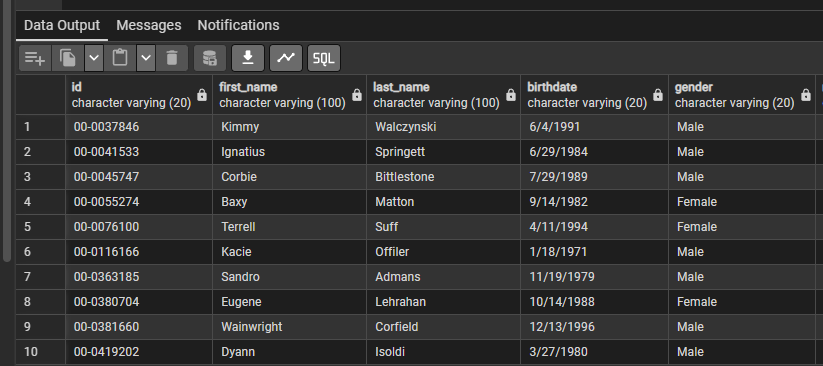

- ***STEP 2:***

```sql
ALTER TABLE hr
RENAME COLUMN id TO emp_id;
```

- ***STEP 3:***

```sql
SELECT * FROM hr;
```

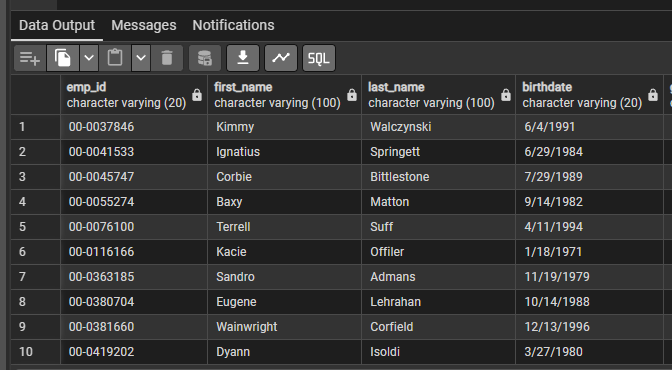

### Setting 'emp_id' column's data type to VARCHAR(20) and constraint to NOT NULL:

- ***STEP 1:***

```sql
ALTER TABLE hr
ALTER COLUMN emp_id TYPE VARCHAR(20),
ALTER COLUMN emp_id SET NOT NULL;
```

- ***STEP 2: Describe Table 'hr'***

    - Open PSQL tool: Tools → PSQL Tool
    - Run: \d hr
    - NOTE: \d stands for describe

    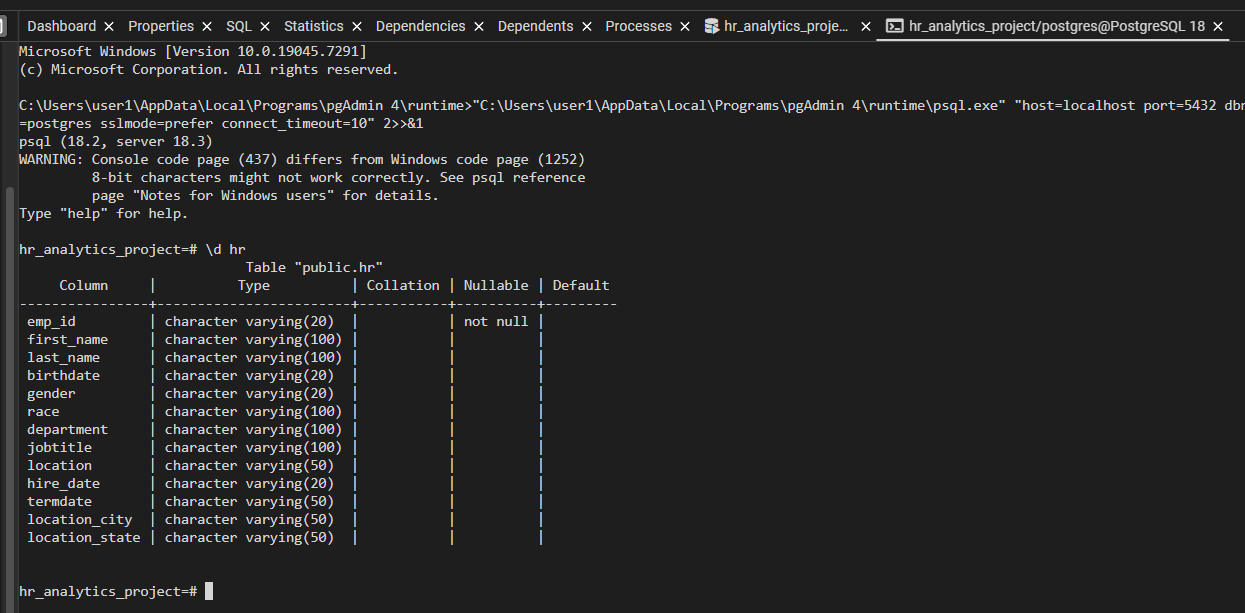

---

# 'birthdate' column.

### Adding Format Variations to Birthdate Column(creating anomalies):

```sql
SELECT emp_id, birthdate FROM hr
ORDER BY emp_id ASC
LIMIT 3;
```

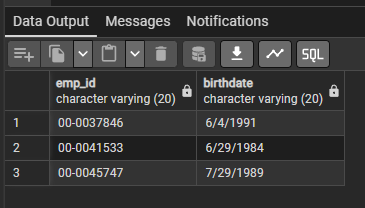

```sql
UPDATE hr
SET birthdate =
    CASE
        WHEN emp_id = '00-0037846' THEN '6-4-1991'
        WHEN emp_id = '00-0041533' THEN '6-29-1984'
        WHEN emp_id = '00-0045747' THEN '7-29-1989'
    END
WHERE emp_id IN ('00-0037846','00-0041533','00-0045747');
```

- ***Verifying:***

```sql
SELECT emp_id, birthdate FROM hr
ORDER BY emp_id ASC
LIMIT 3;
```

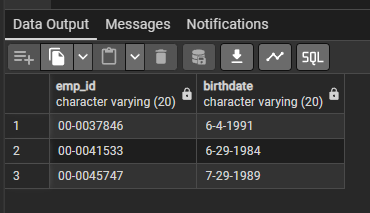

### Find distinct 'birthdate' column patterns:

```sql
SELECT DISTINCT
	regexp_replace(birthdate, '[0-9]', 'N', 'g') AS pattern
FROM hr;
```

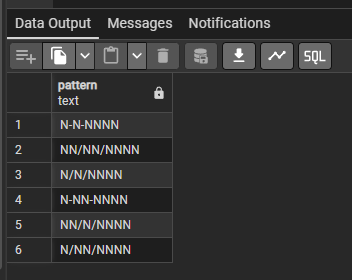

- ***Includes -(dashes) as well as /(forward slash).***

- ***regexp_replace()***
    - regexp_replace() replaces text that matches a regular expression pattern.
    - Syntax: regexp_replace(source_string, pattern, replacement [, flags])
    - 'g' → replace all matches (global)

### Querying few 'birthdate' column values:

```sql
SELECT birthdate FROM hr
LIMIT 20;
```

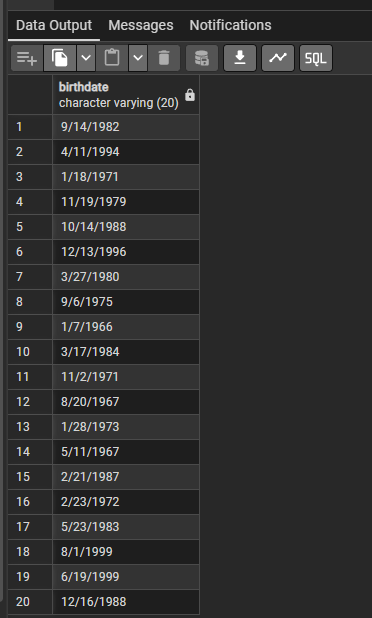

- ***Follows MM/DD/YYYY format.***

### Convert Birthdate from VARCHAR (MM/DD/YYYY & MM-DD-YYYY) to DATE:

```sql
ALTER TABLE hr
ALTER COLUMN birthdate TYPE DATE
USING(
    CASE
        WHEN birthdate LIKE '%/%' 
            THEN TO_DATE(birthdate,'MM/DD/YYYY')
        WHEN birthdate LIKE '%-%' 
            THEN TO_DATE(birthdate,'MM-DD-YYYY')
    END
);
```

- ***USING()***
    - Defines how existing column values are converted to the new data type.
    - Syntax: USING (conversion_expression)
- ***% is a wildcard character that matches zero or more characters.***
    - Examples: birthdate LIKE '%/%' → Contains / anywhere in the string.
- ***TO_DATE()***
    - Converts a text string into a PostgreSQL DATE value.
    - Syntax: TO_DATE(text_column, format_of_text_in_column)

### Verify using describe(\d)

- Open PSQL tool: Tools → PSQL Tool
- Run: \d hr (make sure that it is the right db, hr_analytics_project)

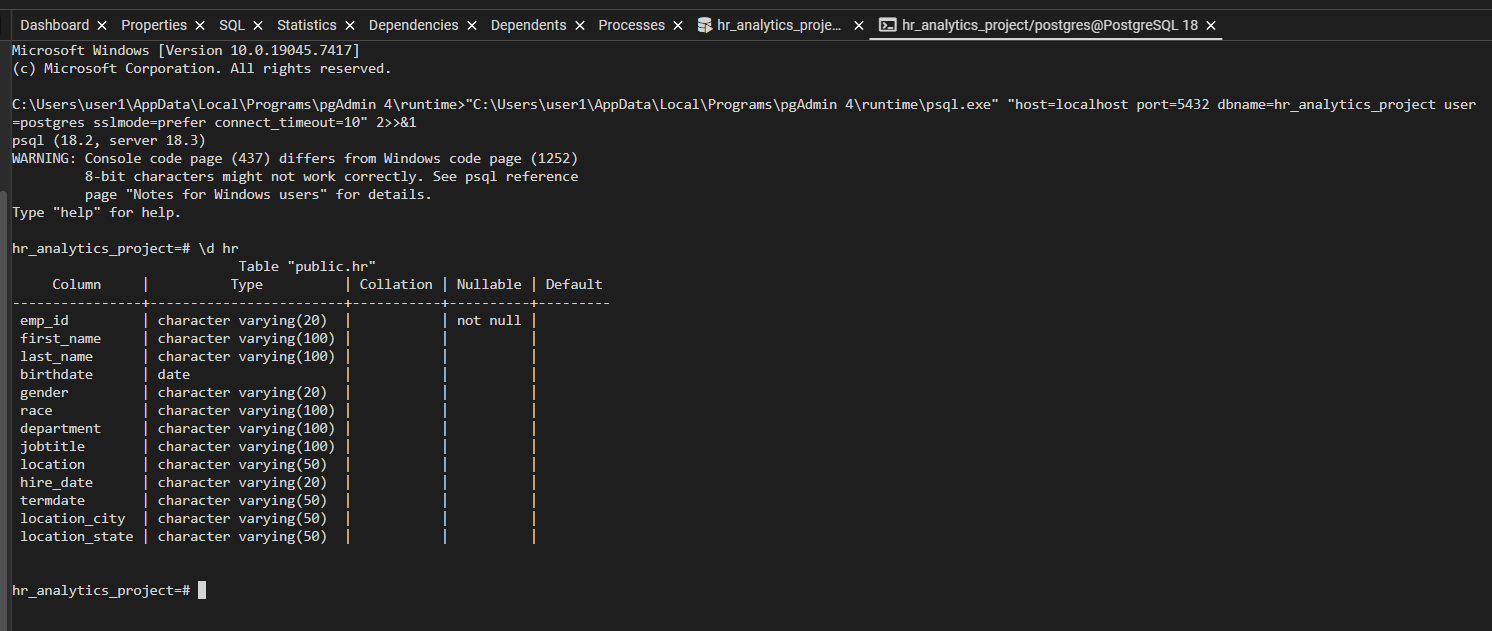

### Verify by Querying few 'birthdate' column values:

```sql
SELECT birthdate FROM hr
LIMIT 20;
```

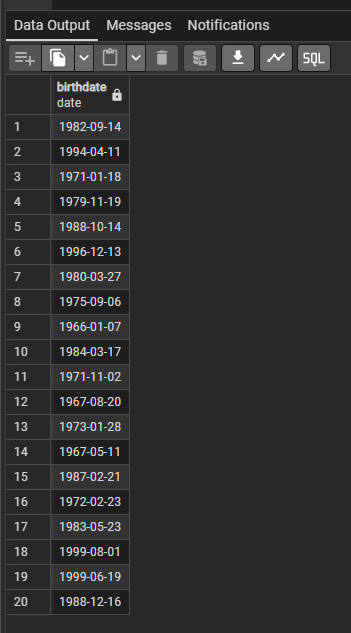

---

# 'hire_date' column.

### Find distinct 'hire_date' column patterns:

```sql
SELECT DISTINCT
	regexp_replace(hire_date, '[0-9]', 'N', 'g') AS pattern
FROM hr;
```

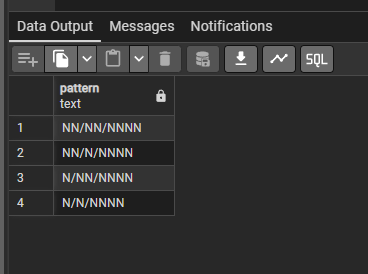

- ***Includes only /(forward slash).***

### Querying few 'hire_date' column values:

```sql
SELECT hire_date FROM hr
LIMIT 20;
```

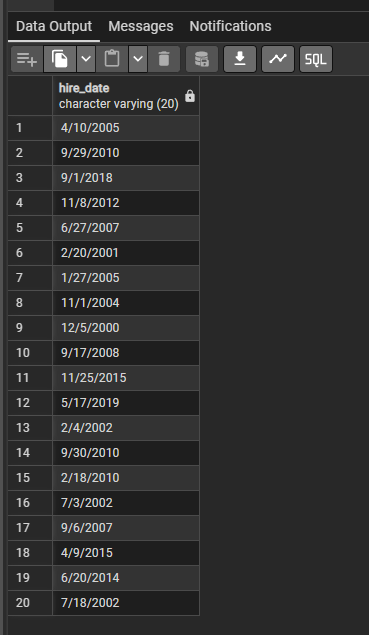

- ***Follows MM/DD/YYYY format.***

### Convert hire_date from VARCHAR (MM/DD/YYYY) to DATE:

```sql
ALTER TABLE hr
ALTER COLUMN hire_date TYPE DATE
USING(
	TO_DATE(hire_date, 'MM/DD/YYYY')
	);
```

### Verify using describe(\d):

- Open PSQL tool: Tools → PSQL Tool
- Run: \d hr (make sure that it is the right db, hr_analytics_project)

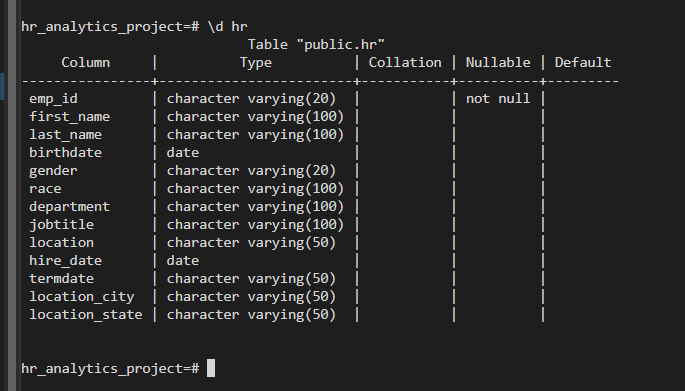

### Verify by Querying few 'hire_date' column values:

```sql
SELECT hire_date FROM hr
LIMIT 20;
```

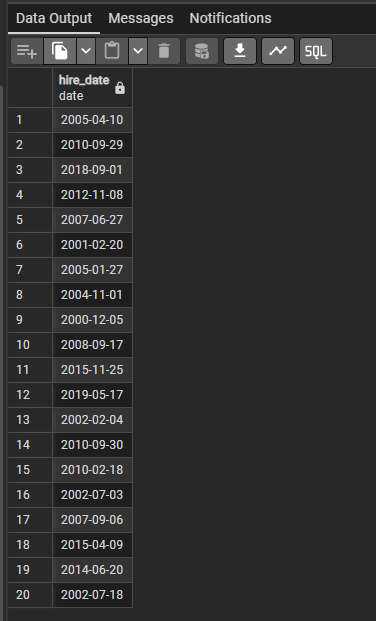

---

# 'termdate' column.

### Find distinct 'termdate' column patterns:

```sql
SELECT DISTINCT
	regexp_replace(termdate, '[0-9]', 'N', 'g') AS pattern
FROM hr;
```

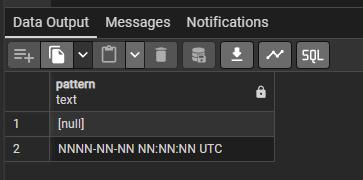

- ***Contains timestamp and null values.***

### Querying few 'termdate' column values:

```sql
SELECT termdate FROM hr
WHERE termdate IS NOT NULL
LIMIT 20;
```

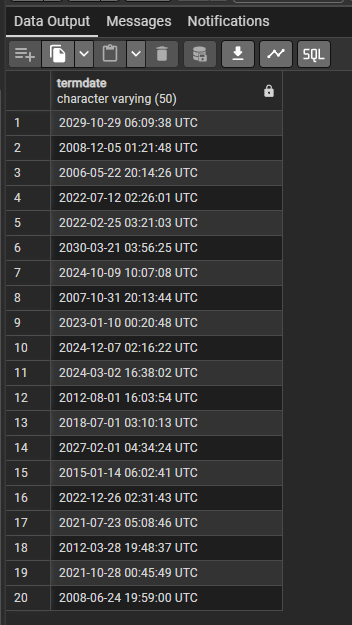

- ***Follows YYYY-MM-DD HH:MI:SS UTC format.***

### Convert termdate from VARCHAR (YYYY-MM-DD HH:MI:SS UTC ) to DATE:

```sql
ALTER TABLE hr
ALTER COLUMN termdate TYPE DATE
USING(
    CASE
        WHEN termdate IS NULL THEN NULL
        ELSE CAST(termdate AS TIMESTAMP)::DATE
    END
);
```

- ***CAST()***
    - CAST() converts a value from one data type to another.
    - Syntax: CAST(expression AS target_data_type)
- CAST(termdate AS TIMESTAMP) ⟶ Converts from VARCHAR value to TIMESTAMP value
- ::DATE ⟶ Removes the time portion(:: = type cast operator)
- VARCHAR → TIMESTAMP → DATE

### Verify using describe(\d):

- Open PSQL tool: Tools → PSQL Tool
- Run: \d hr (make sure that it is the right db, hr_analytics_project)

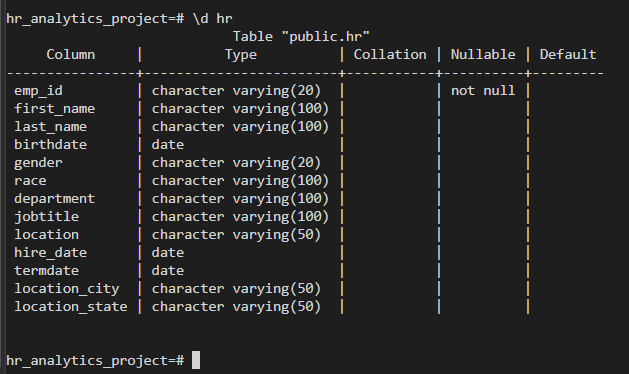

### Verify by Querying few 'hire_date' column values:

```sql
SELECT termdate FROM hr
LIMIT 20;
```

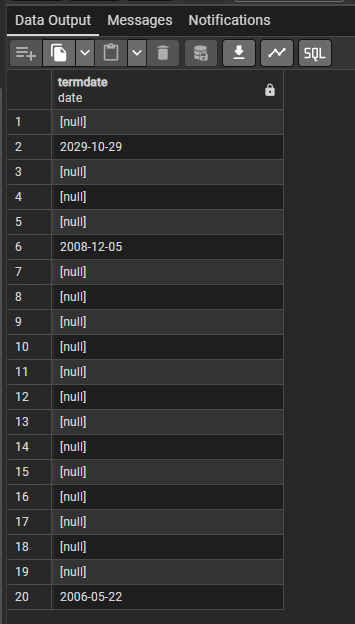

---

# Checking NULL Values

```sql
SELECT
	COUNT(*) - COUNT(first_name) AS first_name_nulls,
	COUNT(*) - COUNT(last_name) AS last_name_nulls,
	COUNT(*) - COUNT(birthdate) AS birthdate_nulls,
	COUNT(*) - COUNT(gender) AS gender_nulls,
	COUNT(*) - COUNT(race) AS race_nulls,
	COUNT(*) - COUNT(department) AS department_nulls,
	COUNT(*) - COUNT(jobtitle) AS jobtitle_nulls,
	COUNT(*) - COUNT(location) AS location_nulls,
	COUNT(*) - COUNT(hire_date) AS hire_date_nulls,
	COUNT(*) - COUNT(termdate) AS termdate_nulls,
	COUNT(*) - COUNT(location_city) AS location_city_nulls,
	COUNT(*) - COUNT(location_state) AS location_state_nulls
FROM hr;
```

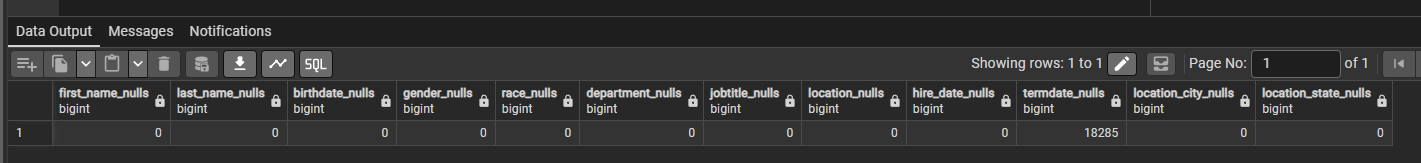

- ***termdate: Null values indicate active employees with no termination date.***

---